# M5 Forecasting - Model Training and Evaluation

This notebook demonstrates:
- Feature engineering
- Model training with XGBoost and LightGBM
- Baseline comparison (naive lag-1, seasonal lag-7, rolling mean 7d) vs ML models
- Model evaluation and comparison
- After training: metrics, learning curves, feature importance per model, daily actual vs predictions + baselines, then sample series and residual plot for each model (e.g. XGBoost and LightGBM)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append('..')

from src.pipeline.train_pipeline import TrainingPipeline
from src.utils.config import load_config
from src.evaluation.plots import display_training_report_plots

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# Initialize training pipeline
pipeline = TrainingPipeline(config_path='../configs/config.m5_optimized.yaml')

In [ ]:
# Run training pipeline (charts are shown in the next cell)
models, results, plot_ctx = pipeline.run(return_plot_inputs=True)

2026-04-17 17:18:14,514 - src.pipeline.train_pipeline - INFO - ============================================================
2026-04-17 17:18:14,515 - src.pipeline.train_pipeline - INFO - Starting Training Pipeline
2026-04-17 17:18:14,515 - src.pipeline.train_pipeline - INFO - ============================================================


/Users/chuhoangphucthanh/workspace/projects/retail-demand-forecasting/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


2026-04-17 17:18:14,892 - src.pipeline.train_pipeline - INFO - Loading data...
2026-04-17 17:18:14,893 - src.data.loader - INFO - Loading calendar from /Users/chuhoangphucthanh/workspace/projects/retail-demand-forecasting/data/raw/calendar.csv
2026-04-17 17:18:14,898 - src.data.loader - INFO - Loading sales from /Users/chuhoangphucthanh/workspace/projects/retail-demand-forecasting/data/raw/sales_train_validation.csv
2026-04-17 17:18:16,132 - src.data.loader - INFO - Loading prices from /Users/chuhoangphucthanh/workspace/projects/retail-demand-forecasting/data/raw/sell_prices.csv
2026-04-17 17:18:17,163 - src.data.loader - INFO - Creating base dataset
2026-04-17 17:18:17,184 - src.data.loader - INFO - Subsampled sales (random): 1000 of 30490 items (seed=42)
2026-04-17 17:18:17,185 - src.data.loader - INFO - Reshaping sales data to long format (memory-optimized)
2026-04-17 17:18:17,202 - src.data.loader - INFO - Processing 1000 products × 1913 days = 1,913,000 rows
2026-04-17 17:18:18,12

/Users/chuhoangphucthanh/workspace/projects/retail-demand-forecasting/notebooks/../src/features/engineering.py:171: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['price_change'] = df.groupby(group_cols)['sell_price'].pct_change()


2026-04-17 17:18:21,610 - src.features.engineering - INFO - Creating event features
2026-04-17 17:18:21,897 - src.features.engineering - INFO - Creating lag features: [1, 7, 14, 28, 56]
2026-04-17 17:18:22,128 - src.features.engineering - INFO - Creating rolling features: windows=[7, 14, 28], functions=['mean', 'std', 'max']


...

2026-04-17 17:18:23,014 - src.pipeline.train_pipeline - INFO - Prepared 49 features
2026-04-17 17:18:23,042 - src.pipeline.train_pipeline - INFO - Splitting data...
2026-04-17 17:18:23,996 - src.pipeline.train_pipeline - INFO - Train: 1857000 rows (2011-01-29 00:00:00 to 2016-02-28 00:00:00)
2026-04-17 17:18:23,996 - src.pipeline.train_pipeline - INFO - Validation: 28000 rows (2016-02-29 00:00:00 to 2016-03-27 00:00:00)
2026-04-17 17:18:23,996 - src.pipeline.train_pipeline - INFO - Test: 28000 rows (2016-03-28 00:00:00 to 2016-04-24 00:00:00)
2026-04-17 17:18:24,043 - src.pipeline.train_pipeline - INFO - Training models...
2026-04-17 17:18:24,288 - src.models.trainer - INFO - Training XGBoost model
2026-04-17 17:18:34,061 - src.models.trainer - INFO - XGBoost training completed. Best iteration: 406
2026-04-17 17:18:34,062 - src.models.trainer - INFO - Training LightGBM model
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048067 seconds.
You can 

2026/04/17 17:18:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026-04-17 17:18:43,914 - src.utils.mlflow_tracking - WARNING - MLflow log_model failed for xgboost (Invalid model name ('models/xgboost') provided. Model name must be a non-empty string and cannot contain the following characters: ('/', ':', '.', '%', '"', "'")); logging joblib artifact


2026/04/17 17:18:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026-04-17 17:18:43,924 - src.utils.mlflow_tracking - WARNING - MLflow log_model failed for lightgbm (Invalid model name ('models/lightgbm') provided. Model name must be a non-empty string and cannot contain the following characters: ('/', ':', '.', '%', '"', "'")); logging joblib artifact
2026-04-17 17:18:43,927 - src.pipeline.train_pipeline - INFO - 
2026-04-17 17:18:43,928 - src.pipeline.train_pipeline - INFO - Training Pipeline Completed
2026-04-17 17:18:43,928 - src.pipeline.train_pipeline - INFO - ============================================================


### Train / eval — figures

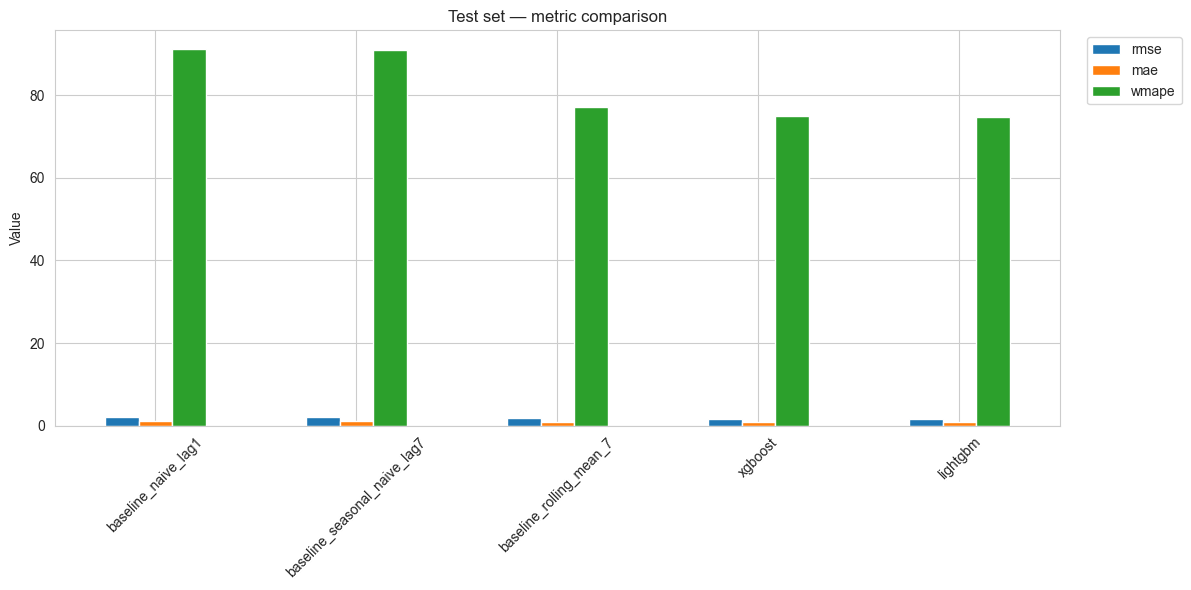

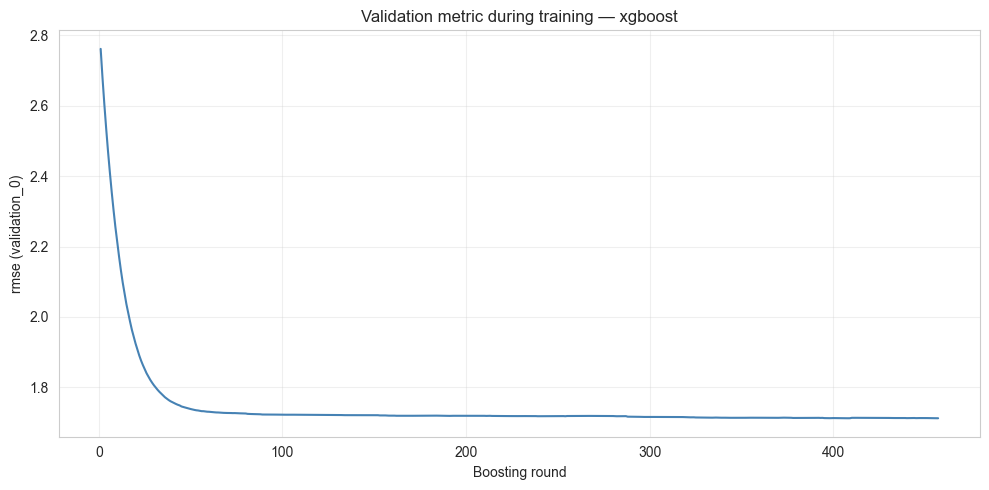

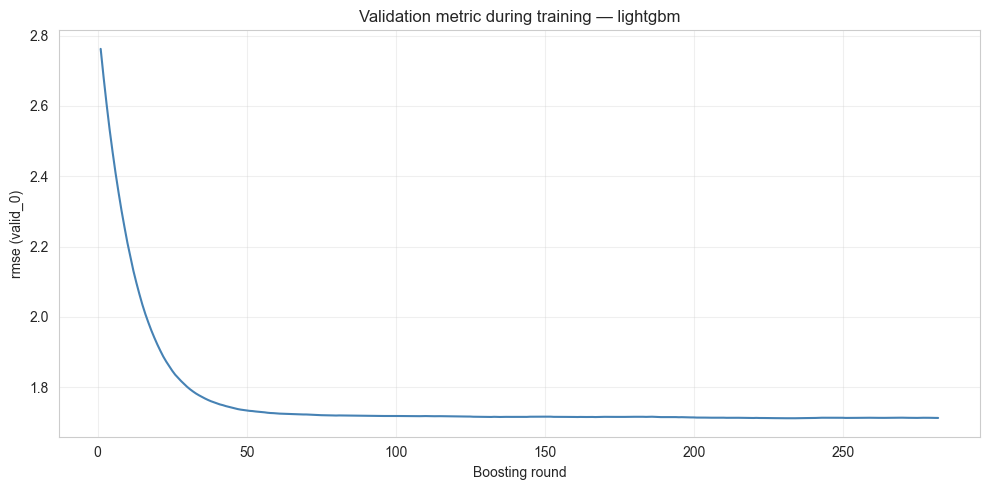

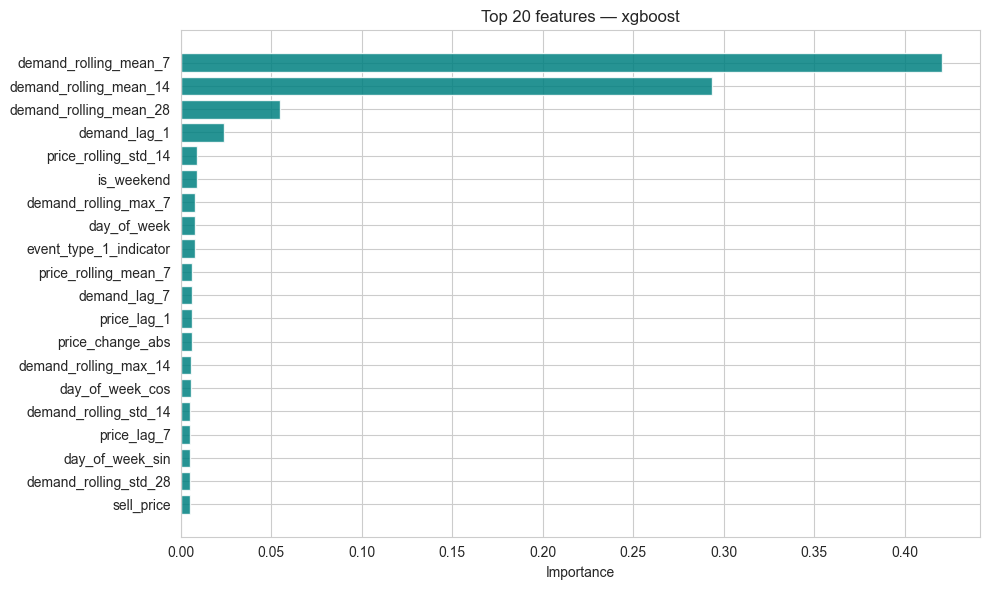

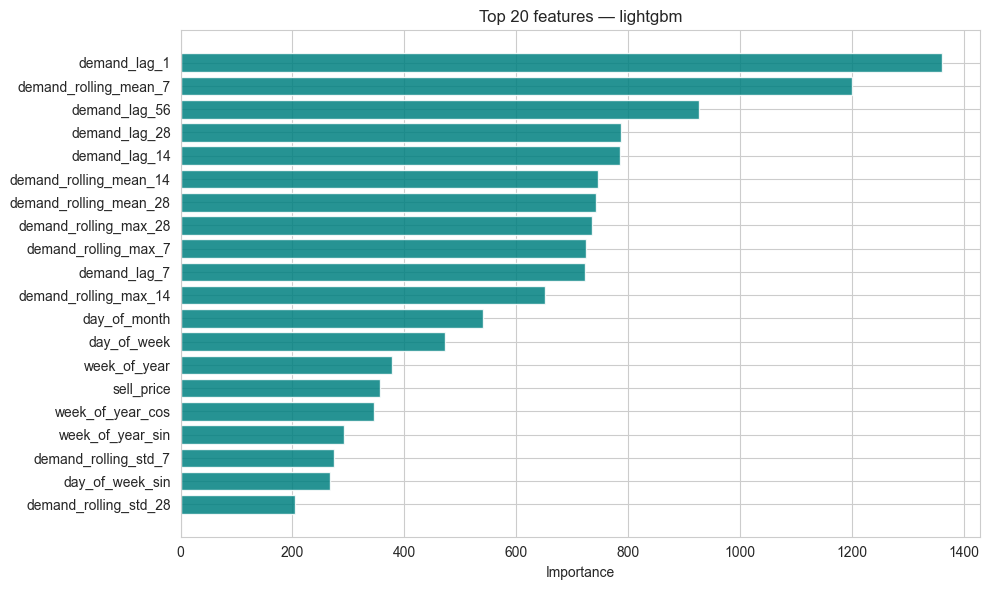

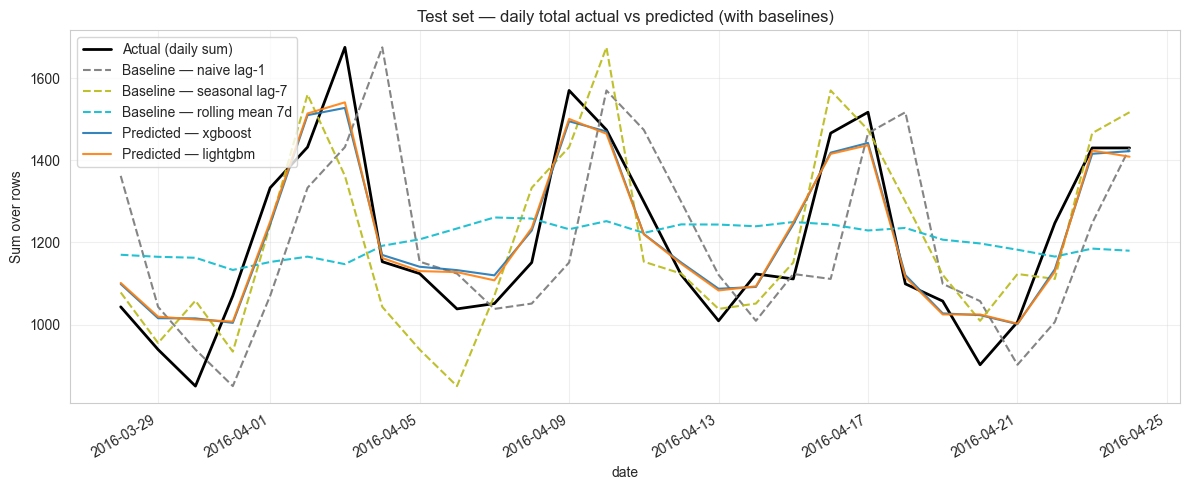

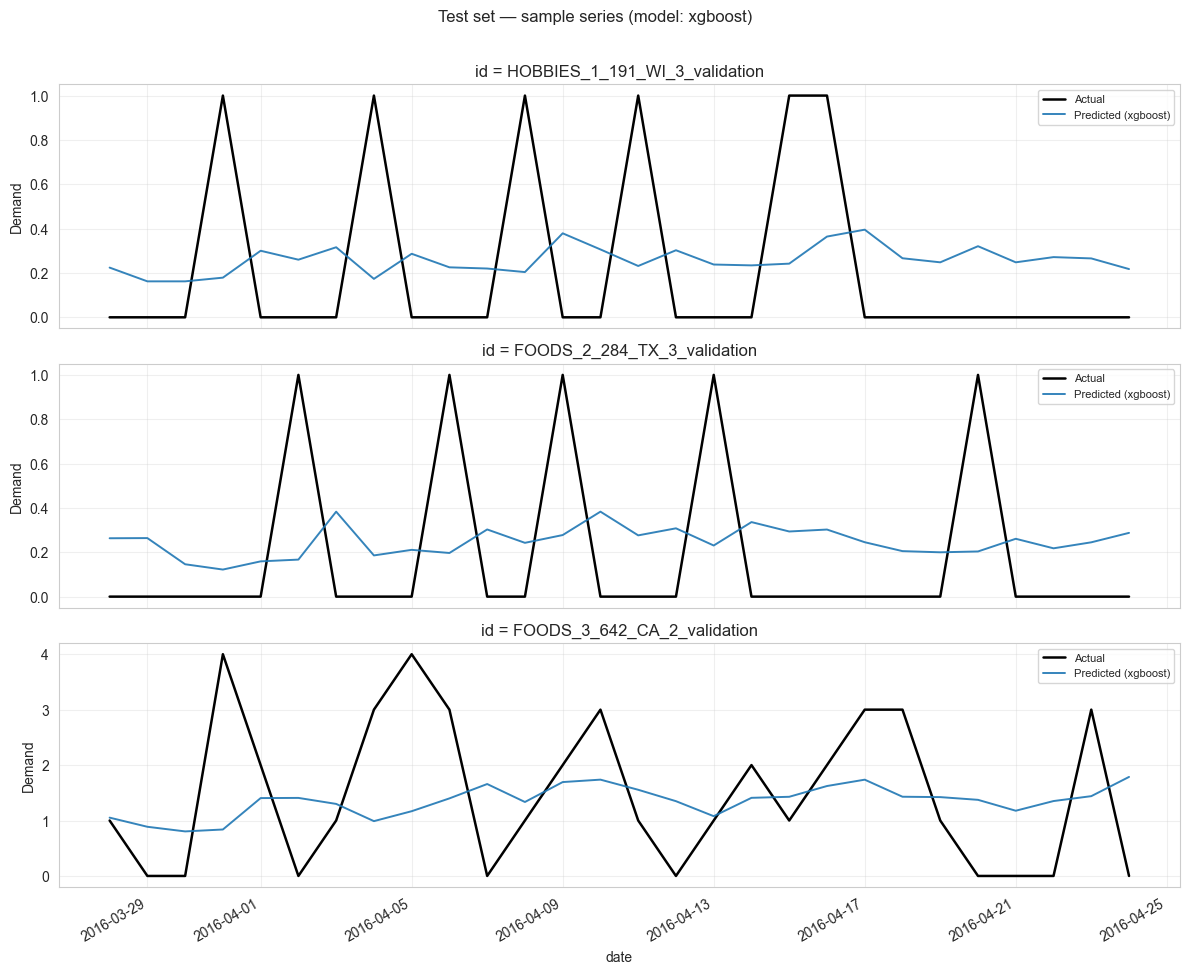

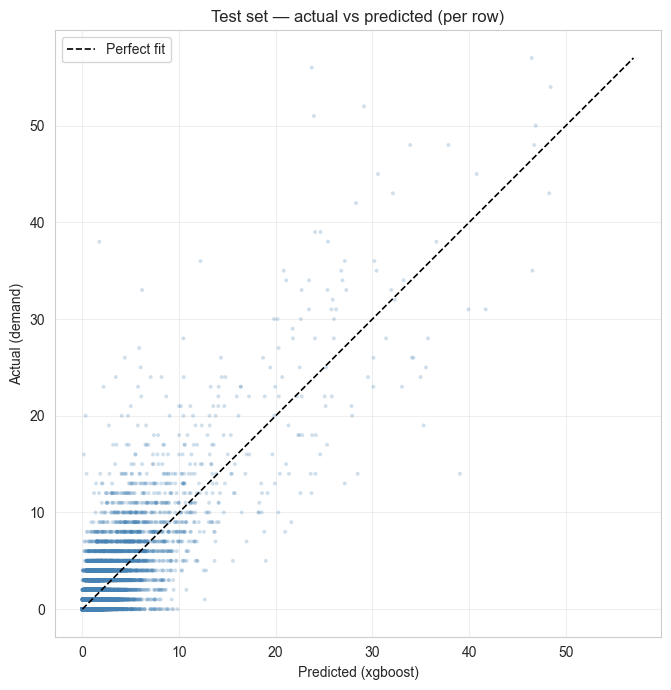

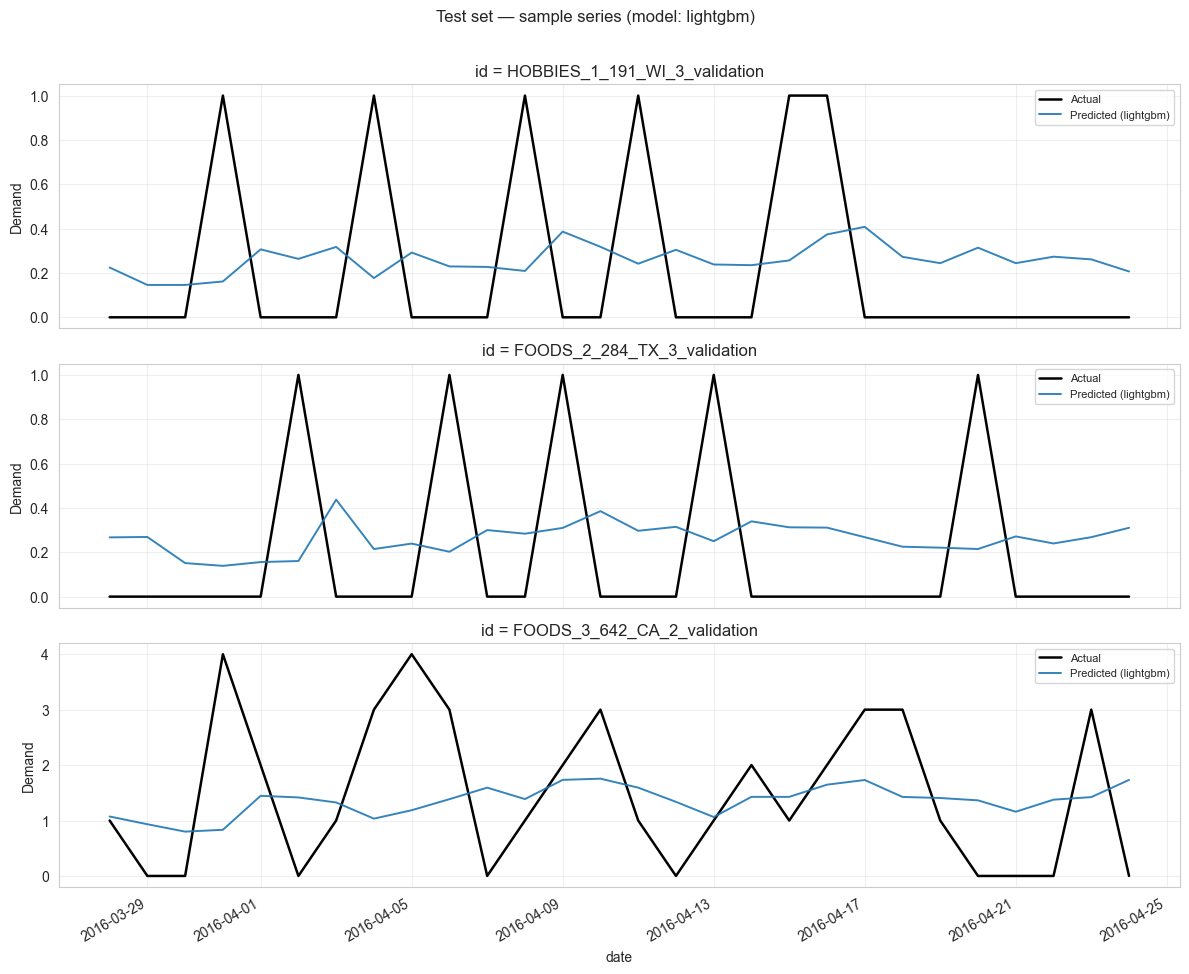

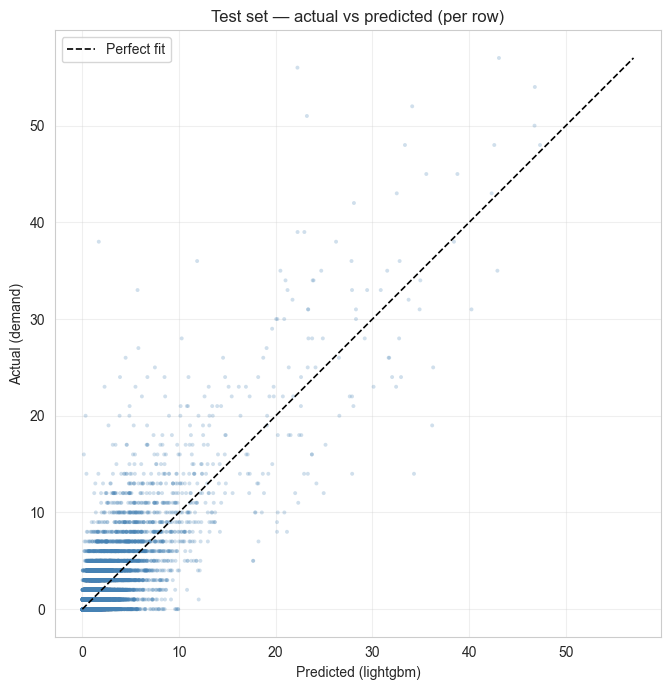

In [ ]:
# Figures: metrics → learning curves + FI per model → daily (ML + baselines) →
# sample series + residual scatter for each trained model (xgboost & lightgbm by default).
from IPython.display import Markdown, display

display(Markdown("### Train / eval — figures"))
training_cfg = pipeline.config.get("training", {}) or {}
display_training_report_plots(
    test_results=results,
    test_df=plot_ctx["test_df"],
    feature_cols=plot_ctx["feature_cols"],
    model_trainer=pipeline.model_trainer,
    date_col=training_cfg.get("date_col", "date"),
    target_col=training_cfg.get("target_col", "demand"),
    # forecast_models="lightgbm"  # hoặc ("xgboost", "lightgbm"); bỏ dòng để vẽ mọi model
)


In [ ]:
# Compare model performance (numeric table; bar chart is in the figures cell above)
comparison_df = pd.DataFrame(results).T
print("Model Comparison:")
print(comparison_df)

Model Comparison:
                                  rmse       mae      wmape
baseline_naive_lag1           2.216561  1.097500  91.132859
baseline_seasonal_naive_lag7  2.210365  1.095429  90.960854
baseline_rolling_mean_7       1.751600  0.928602  77.108117
xgboost                       1.626430  0.902084  74.906178
lightgbm                      1.620070  0.900004  74.733402


In [ ]:
# Feature importance (bar charts are in the figures cell above)
for model_name in models.keys():
    importance_df = pipeline.model_trainer.get_feature_importance(model_name, top_n=20)
    print(f"\nTop 20 Features - {model_name.upper()}:")
    print(importance_df)


Top 20 Features - XGBOOST:
                   feature  importance
40   demand_rolling_mean_7    0.420615
43  demand_rolling_mean_14    0.293769
46  demand_rolling_mean_28    0.054984
35            demand_lag_1    0.023919
28    price_rolling_std_14    0.009101
8               is_weekend    0.008925
42    demand_rolling_max_7    0.008225
4              day_of_week    0.008220
32  event_type_1_indicator    0.007764
25    price_rolling_mean_7    0.006552
36            demand_lag_7    0.006499
19             price_lag_1    0.006459
24        price_change_abs    0.006142
45   demand_rolling_max_14    0.005992
14         day_of_week_cos    0.005636
44   demand_rolling_std_14    0.005369
20             price_lag_7    0.005367
13         day_of_week_sin    0.005251
47   demand_rolling_std_28    0.005235
3               sell_price    0.005224

Top 20 Features - LIGHTGBM:
                   feature  importance
35            demand_lag_1        1361
40   demand_rolling_mean_7        1201
39     